# Supermassive Black Hole Mass Envelope
**Horizon-Scaled Saturation and Rare-Event Formation of Early Supermassive Black Holes**

*Author: Eric C. Thompson*

https://orcid.org/0009-0001-4127-1742

This notebook generates the high-redshift ($z > 10$) supermassive black hole capacity envelope based on the kinematic saturation boundary derived in the NDK framework.
It uses the `colossus` package to compute the linear-theory variance $\sigma(R,z)$ using Planck18 parameters.

In [ ]:
# Install required cosmological library
!pip install colossus

Calibrated I*/A = 3.27875 (Planck18 params + Colossus linear variance; p=1e-09, anchor=10×J0313-1806 at z=7.642)


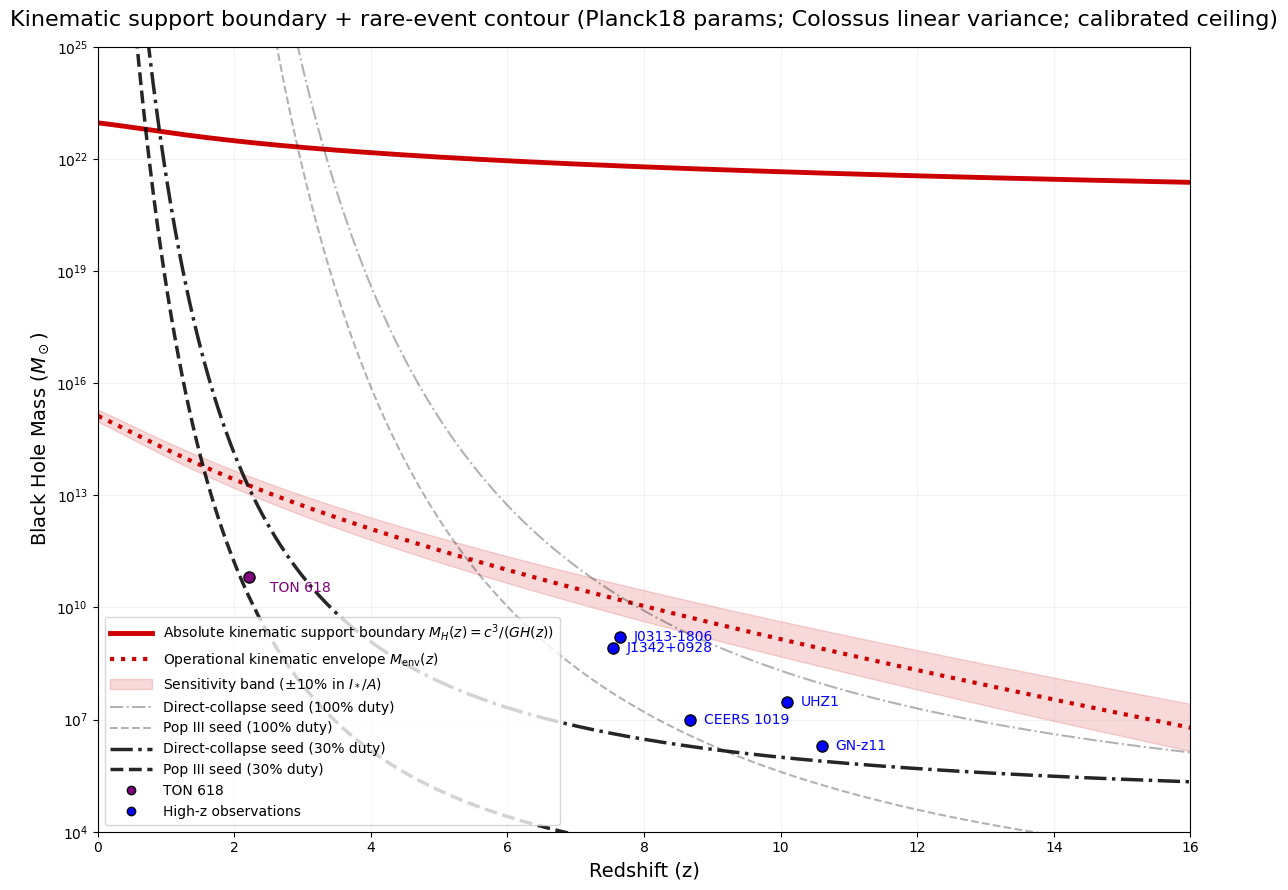

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import astropy.constants as const

from scipy.special import erfcinv
from scipy.interpolate import interp1d

# --- COLOSSUS: linear-theory variance σ(R,z) using Planck18 parameters ---
# Note: Colossus computes σ via an analytic linear transfer function (commonly EH98-style),
# not a full Boltzmann solver unless explicitly configured otherwise.
from colossus.cosmology import cosmology
cosmo_col = cosmology.setCosmology('planck18')  # Planck18 parameters in Colossus

# =================================================
# 1) COSMOLOGY + GRID
# =================================================
cosmo_astro = FlatLambdaCDM(H0=67.66, Om0=0.3111)  # close match to Planck18
z_vals = np.linspace(0.01, 16, 600)

# Absolute kinematic support boundary: M_H(z) = c^3/(G H(z))
H_z = cosmo_astro.H(z_vals).to(u.s**-1)
M_abs = (const.c**3 / (const.G * H_z)).to(u.M_sun).value

# --- Mass -> Lagrangian radius mapping ---
# Convention: comoving top-hat radius enclosing mass M using mean matter density rho_m0.
rho_crit0 = cosmo_astro.critical_density0.to(u.kg/u.m**3).value
rho_m0 = rho_crit0 * cosmo_astro.Om0

Mpc_to_m = (u.Mpc).to(u.m)
h = cosmo_astro.H0.value / 100.0

def get_sigma_M(M_Msun, z):
    """
    Returns linear-theory rms variance σ(R,z) from Colossus at redshift z.

    Mapping:
      M -> R via a comoving top-hat window over mean matter density rho_m0:
        R = [3 M / (4π rho_m0)]^(1/3)

    Colossus expects R in (Mpc/h).
    """
    M_kg = M_Msun * const.M_sun.value
    R_m = (3.0 * M_kg / (4.0 * np.pi * rho_m0))**(1.0/3.0)
    R_Mpch = (R_m / Mpc_to_m) * h
    return cosmo_col.sigma(R_Mpch, z)

# =================================================
# 2) RARE-EVENT CONTOUR: P_sat = p via erfc tail
# =================================================
# Chosen constant tail probability level for the contour (not derived here).
p = 1e-9

# Anchor object (used ONLY to calibrate the effective parameter I*/A).
# This is not a "prediction"; it is a phenomenological calibration.
z_anchor_bh = 7.642
M_obs_anchor = 1.6e9

# Buffer factor defines an *upper-envelope* (capacity ceiling) rather than a best fit.
buffer_factor = 10.0
M_anchor_target = M_obs_anchor * buffer_factor

# Calibrate effective threshold combination I*/A from anchor:
#   p = 0.5 erfc( (I*/A) / (sqrt2 * σ_R(M,z)) )
# -> I*/A = sqrt2 * σ_R(M,z) * erfcinv(2p)
sigma_anchor = get_sigma_M(M_anchor_target, z_anchor_bh)
Istar_over_A = np.sqrt(2.0) * sigma_anchor * erfcinv(2.0 * p)

print(
    f"Calibrated I*/A = {Istar_over_A:.6g} "
    f"(Planck18 params + Colossus linear variance; p={p:g}, "
    f"anchor={buffer_factor:g}×J0313-1806 at z={z_anchor_bh})"
)

# For the chosen contour level p, the corresponding σ-threshold is:
sigma_thresh_main = Istar_over_A / (np.sqrt(2.0) * erfcinv(2.0 * p))

# =================================================
# 3) FAST INVERSION: solve σ(M,z)=σ_thresh for M(z)
# =================================================
# Build σ(M,z=0) lookup table then scale by linear growth factor D(z):
M_grid = np.logspace(4, 15, 1200)  # Msun grid for inversion
sigma_z0_grid = get_sigma_M(M_grid, 0.0)

# Ensure monotonic interpolation input (defensive programming).
# For the relevant mass range σ generally decreases with M, but sort anyway.
sort_idx = np.argsort(sigma_z0_grid)
sigma_sorted = sigma_z0_grid[sort_idx]
M_sorted = M_grid[sort_idx]

# Interpolate log(sigma) -> log(M)
f_interp_logM_of_logsig = interp1d(
    np.log(sigma_sorted),
    np.log(M_sorted),
    kind='cubic',
    fill_value='extrapolate',
    bounds_error=False
)

D_vals = cosmo_col.growthFactor(z_vals)  # linear growth factor

def contour_mass_from_sigma_thresh(target_sigma_z):
    """
    Given target σ(M,z), solve for M using:
      σ(M,z) = D(z) * σ(M,0)
    -> σ(M,0) = target / D(z)
    then invert σ(M,0) -> M via interpolation.
    """
    required_sigma_z0 = target_sigma_z / D_vals
    M_contour_vals = np.exp(f_interp_logM_of_logsig(np.log(required_sigma_z0)))
    # Enforce kinematic cap:
    return np.minimum(M_contour_vals, M_abs)

M_contour = contour_mass_from_sigma_thresh(sigma_thresh_main)

# Sensitivity band: ±10% in calibrated parameter I*/A (not a derived theory error bar)
frac_unc = 0.10
I_lo = Istar_over_A * (1.0 - frac_unc)
I_hi = Istar_over_A * (1.0 + frac_unc)

sigma_thresh_lo = I_lo / (np.sqrt(2.0) * erfcinv(2.0 * p))
sigma_thresh_hi = I_hi / (np.sqrt(2.0) * erfcinv(2.0 * p))

M_lo = contour_mass_from_sigma_thresh(sigma_thresh_lo)
M_hi = contour_mass_from_sigma_thresh(sigma_thresh_hi)

M_band_low = np.minimum(M_lo, M_hi)
M_band_high = np.maximum(M_lo, M_hi)

# =================================================
# 4) ACCRETION TRACKS (simple Eddington e-folding model)
# =================================================
def growth_track(z_start, M_seed, duty_cycle=1.0, t_efold_Myr=45.0):
    """
    Exponential mass growth with an e-folding time ~45 Myr at 100% duty cycle.
    This is a schematic comparison, not a full accretion+feedback model.
    """
    t_start = cosmo_astro.age(z_start).to(u.Myr).value
    ages = cosmo_astro.age(z_vals).to(u.Myr).value
    M_track = np.full_like(ages, np.nan, dtype=float)
    for i, age in enumerate(ages):
        if age >= t_start:
            M_track[i] = M_seed * np.exp((duty_cycle * (age - t_start)) / t_efold_Myr)
    return M_track

M_stellar_100 = growth_track(30, 1e2, duty_cycle=1.0)
M_direct_100  = growth_track(25, 1e5, duty_cycle=1.0)

M_stellar_30 = growth_track(30, 1e2, duty_cycle=0.3)
M_direct_30  = growth_track(25, 1e5, duty_cycle=0.3)

# =================================================
# 5) OBSERVATIONAL POINTS (as provided)
# =================================================
data_points = [
    {"name": "TON 618",       "z": 2.22,  "M": 6.6e10, "color": "purple"},
    {"name": "GN-z11",        "z": 10.6,  "M": 2e6,    "color": "blue"},
    {"name": "UHZ1",          "z": 10.1,  "M": 3e7,    "color": "blue"},
    {"name": "CEERS 1019",    "z": 8.679, "M": 1e7,    "color": "blue"},
    {"name": "J0313-1806",    "z": 7.642, "M": 1.6e9,  "color": "blue"},
    {"name": "J1342+0928", "z": 7.54, "M": 8e8, "color": "blue"},
]

# =================================================
# 6) PLOT
# =================================================
plt.figure(figsize=(12, 9))

# Absolute kinematic boundary
plt.plot(
    z_vals, M_abs,
    color='#cc0000', linewidth=3.5,
    label=r'Absolute kinematic support boundary $M_H(z)=c^3/(G H(z))$'
)

# Rare-event contour + sensitivity band (Swapped order here)
plt.plot(
    z_vals, M_contour,
    linestyle=':', color='#cc0000', linewidth=3,
    label=r'Operational kinematic envelope $M_{\rm env}(z)$'
)

plt.fill_between(
    z_vals, M_band_low, M_band_high,
    color='#cc0000', alpha=0.15,
    label=r'Sensitivity band ($\pm 10\%$ in $I_*/A$)'
)

# Accretion tracks
plt.plot(z_vals, M_direct_100, '-.', color='black', alpha=0.3, label='Direct-collapse seed (100% duty)')
plt.plot(z_vals, M_stellar_100, '--', color='black', alpha=0.3, label='Pop III seed (100% duty)')
plt.plot(z_vals, M_direct_30, '-.', color='black', linewidth=2.5, alpha=0.85, label='Direct-collapse seed (30% duty)')
plt.plot(z_vals, M_stellar_30, '--', color='black', linewidth=2.5, alpha=0.85, label='Pop III seed (30% duty)')

# Observational points
for pt in data_points:
    plt.plot(
        pt["z"], pt["M"],
        marker='o', markersize=8,
        color=pt["color"], markeredgecolor='black',
        linestyle='none', zorder=5
    )
    offset_x = 0.2 if pt["name"] != "TON 618" else 0.3
    offset_y = 1.0 if pt["name"] != "TON 618" else 0.5
    plt.text(
        pt["z"] + offset_x, pt["M"] * offset_y,
        pt["name"], color=pt["color"], fontsize=10,
        verticalalignment='center', zorder=5
    )

plt.plot([], [], marker='o', color='purple', markeredgecolor='black', linestyle='none', label='TON 618')
plt.plot([], [], marker='o', color='blue', markeredgecolor='black', linestyle='none', label='High-z observations')

plt.yscale('log')
plt.ylim(1e4, 1e25)
plt.xlim(0, 16)
plt.xlabel('Redshift (z)', fontsize=14)
plt.ylabel(r'Black Hole Mass ($M_\odot$)', fontsize=14)

plt.title(
    r'Kinematic support boundary + rare-event contour '
    r'(Planck18 params; Colossus linear variance; calibrated ceiling)',
    fontsize=16, pad=15
)

plt.grid(True, which='both', alpha=0.15)
plt.legend(loc='lower left', frameon=True, fontsize=10, handlelength=3)
plt.tight_layout()
plt.show()